In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input, LayerNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.utils import to_categorical
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

    # Accuracy Plot (Top)
    axs[0].plot(history.history['accuracy'], label="Train Accuracy")
    axs[0].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axs[0].set_title(f"Model Accuracy - {title}")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="lower right")

    # Loss Plot (Bottom)
    axs[1].plot(history.history['loss'], label="Train Loss")
    axs[1].plot(history.history['val_loss'], label="Validation Loss")
    axs[1].set_title(f"Model Loss - {title}")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Loss")
    axs[1].legend(loc="upper right")

    plt.tight_layout()
    plt.show()


In [4]:
# Load Data
df = pd.read_csv("../parkinson/final_parkinsons_features.csv")

In [5]:
df.head()

,Unnamed: 0,Gait_Cycle_Percent,Left_Ankle_Ankle_Dorsi_Plantarflexion_PF_DF,Left_Hip_Hip_Flexion_Extension_EXT_FLX,Left_Knee_Knee_Flx_Extension_EXT_FLX,Right_Ankle_Ankle_Dorsi_Plantarflexion_PF_DF,Right_Hip_Hip_Flexion_Extension_EXT_FLX,Right_Knee_Knee_Flx_Extension_EXT_FLX,Subject_ID,label,...,Left_Knee_Ang_Knee_Flx_Extension_Variability,Right_Ankle_Ang_Ankle_Dorsi_Plantarflexion_Variability,Right_Hip_Ang_Hip_Flexion_Extension_Variability,Right_Knee_Ang_Knee_Flx_Extension_Variability,Left_Ankle_Ang_Ankle_Dorsi_Plantarflexion_Acceleration,Left_Hip_Ang_Hip_Flexion_Extension_Acceleration,Left_Knee_Ang_Knee_Flx_Extension_Acceleration,Right_Ankle_Ang_Ankle_Dorsi_Plantarflexion_Acceleration,Right_Hip_Ang_Hip_Flexion_Extension_Acceleration,Right_Knee_Ang_Knee_Flx_Extension_Acceleration
0,0,1,-2.37648,34.02794,16.14490,1.87055,33.60558,11.36783,SUB01_1,1,...,18.945746,7.692659,15.308019,18.810668,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,1,2,-1.87879,33.60433,16.86324,0.98626,33.50635,11.34289,SUB01_1,1,...,18.945746,7.692659,15.308019,18.810668,0.49769,-0.42361,0.71834,-0.88429,-0.09923,-0.02494
2,2,3,-1.15549,33.26338,17.86806,0.16397,33.50398,11.92080,SUB01_1,1,...,18.945746,7.692659,15.308019,18.810668,0.72330,-0.34095,1.00482,-0.82229,-0.00237,0.57791
3,3,4,-0.21892,33.00112,19.09299,-0.47002,33.58014,13.01924,SUB01_1,1,...,18.945746,7.692659,15.308019,18.810668,0.93657,-0.26226,1.22493,-0.63399,0.07616,1.09844
4,4,5,0.88757,32.78223,20.42713,-0.80742,33.70621,14.51952,SUB01_1,1,...,18.945746,7.692659,15.308019,18.810668,1.10649,-0.21889,1.33414,-0.33740,0.12607,1.50028


In [6]:
df_clean = df.dropna()

# Then split into X and y
X = df_clean.drop(columns=["label","Gait_Cycle_Percent","Subject_ID","Unnamed: 0"])
y = df_clean["label"]

In [7]:
X.head()

,Left_Ankle_Ankle_Dorsi_Plantarflexion_PF_DF,Left_Hip_Hip_Flexion_Extension_EXT_FLX,Left_Knee_Knee_Flx_Extension_EXT_FLX,Right_Ankle_Ankle_Dorsi_Plantarflexion_PF_DF,Right_Hip_Hip_Flexion_Extension_EXT_FLX,Right_Knee_Knee_Flx_Extension_EXT_FLX,Left_Ankle_Ang_Ankle_Dorsi_Plantarflexion_Variability,Left_Hip_Ang_Hip_Flexion_Extension_Variability,Left_Knee_Ang_Knee_Flx_Extension_Variability,Right_Ankle_Ang_Ankle_Dorsi_Plantarflexion_Variability,Right_Hip_Ang_Hip_Flexion_Extension_Variability,Right_Knee_Ang_Knee_Flx_Extension_Variability,Left_Ankle_Ang_Ankle_Dorsi_Plantarflexion_Acceleration,Left_Hip_Ang_Hip_Flexion_Extension_Acceleration,Left_Knee_Ang_Knee_Flx_Extension_Acceleration,Right_Ankle_Ang_Ankle_Dorsi_Plantarflexion_Acceleration,Right_Hip_Ang_Hip_Flexion_Extension_Acceleration,Right_Knee_Ang_Knee_Flx_Extension_Acceleration
0,-2.37648,34.02794,16.14490,1.87055,33.60558,11.36783,7.157319,15.30818,18.945746,7.692659,15.308019,18.810668,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,-1.87879,33.60433,16.86324,0.98626,33.50635,11.34289,7.157319,15.30818,18.945746,7.692659,15.308019,18.810668,0.49769,-0.42361,0.71834,-0.88429,-0.09923,-0.02494
2,-1.15549,33.26338,17.86806,0.16397,33.50398,11.92080,7.157319,15.30818,18.945746,7.692659,15.308019,18.810668,0.72330,-0.34095,1.00482,-0.82229,-0.00237,0.57791
3,-0.21892,33.00112,19.09299,-0.47002,33.58014,13.01924,7.157319,15.30818,18.945746,7.692659,15.308019,18.810668,0.93657,-0.26226,1.22493,-0.63399,0.07616,1.09844
4,0.88757,32.78223,20.42713,-0.80742,33.70621,14.51952,7.157319,15.30818,18.945746,7.692659,15.308019,18.810668,1.10649,-0.21889,1.33414,-0.33740,0.12607,1.50028


In [8]:
from sklearn.kernel_approximation import RBFSampler

# Step 1: Full RFF transformation using best params
rff = RBFSampler(gamma=0.1, n_components=16, random_state=42)  # You can tune n_components
X_rff_all = rff.fit_transform(X)

n_pca = 4

# Step 2: Train/val split (after RFF)
X_train_full, X_val_full, y_train, y_val = train_test_split(X_rff_all, y, test_size=0.2, random_state=42)

# Step 3: Apply PCA (cap to max dim if needed)
pca = PCA(n_components=4)
X_train_pca = pca.fit_transform(X_train_full)
X_val_pca = pca.transform(X_val_full)

# Step 4: Reshape for RNN
X_train_rnn = X_train_pca.reshape(-1, 1, n_pca)
X_val_rnn = X_val_pca.reshape(-1, 1, n_pca)

# Step 5: Define final model
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(1, X_train_rnn.shape[2])),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# Compile
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0002, clipvalue=0.5),
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Train
history = model.fit(X_train_rnn, y_train, epochs=30, validation_data=(X_val_rnn, y_val), batch_size=32, verbose=1)

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.5263 - loss: 0.6930 - val_accuracy: 0.5412 - val_loss: 0.6925
Epoch 2/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5263 - loss: 0.6927 - val_accuracy: 0.5402 - val_loss: 0.6919
Epoch 3/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5271 - loss: 0.6923 - val_accuracy: 0.5495 - val_loss: 0.6914
Epoch 4/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5338 - loss: 0.6918 - val_accuracy: 0.5588 - val_loss: 0.6909
Epoch 5/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5348 - loss: 0.6914 - val_accuracy: 0.5577 - val_loss: 0.6905
Epoch 6/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5330 - loss: 0.6909 - val_accuracy: 0.5464 - val_loss: 0.6903
Epoch 7/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5317 - loss: 0.6905 - val_accuracy: 0.5495 - val_loss: 0.6897
Epoch 8/30
122/122 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5343 - loss: 0.6900 - val_accuracy: 0

In [9]:
# ✅ Evaluate
test_loss, test_acc = model.evaluate(X_val_rnn, y_val)
print(f"RFF ENN PD Test Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5309 - loss: 0.6898
RFF ENN PD Test Accuracy: 0.5309 | Loss: 0.6898


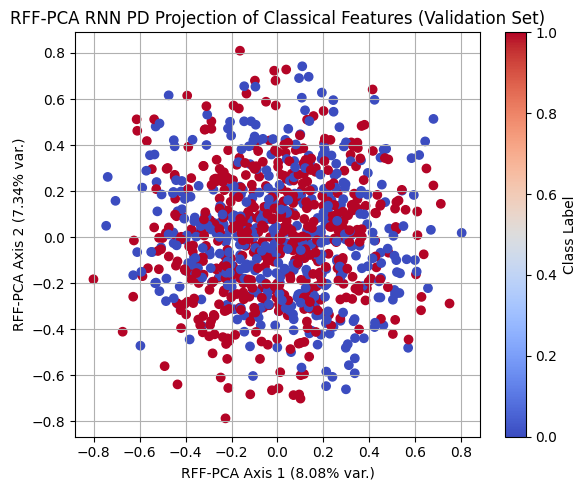

In [10]:
import matplotlib.pyplot as plt

# Project the validation data to 2D using a new PCA for visualization
pca_vis = PCA(n_components=2)
X_val_vis = pca_vis.fit_transform(X_val_full)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(X_val_vis[:, 0], X_val_vis[:, 1], c=y_val, cmap="coolwarm" )
plt.xlabel(f"RFF-PCA Axis 1 ({pca_vis.explained_variance_ratio_[0]*100:.2f}% var.)")
plt.ylabel(f"RFF-PCA Axis 2 ({pca_vis.explained_variance_ratio_[1]*100:.2f}% var.)")
plt.title("RFF-PCA RNN PD Projection of Classical Features (Validation Set)")
plt.colorbar(label="Class Label")
plt.grid(True)
plt.tight_layout()
plt.show()


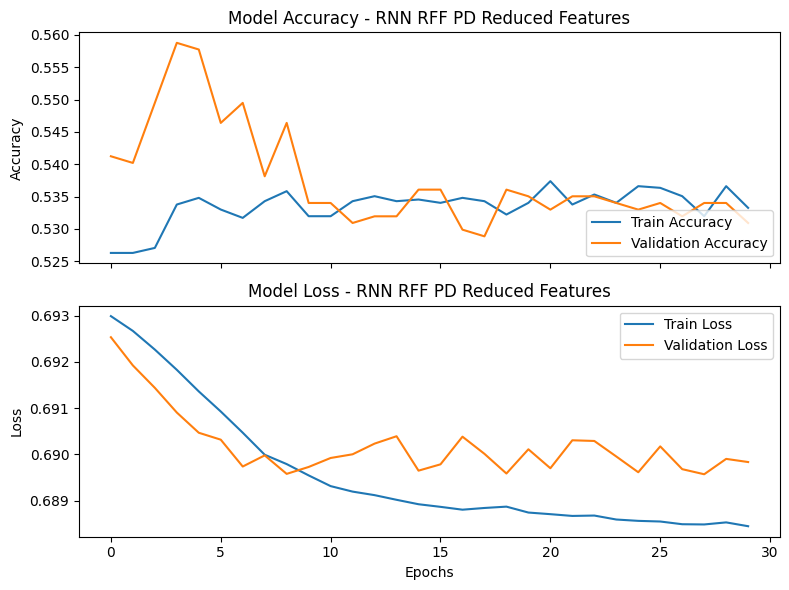

In [11]:
plot_history(history, "RNN RFF PD Reduced Features")

31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


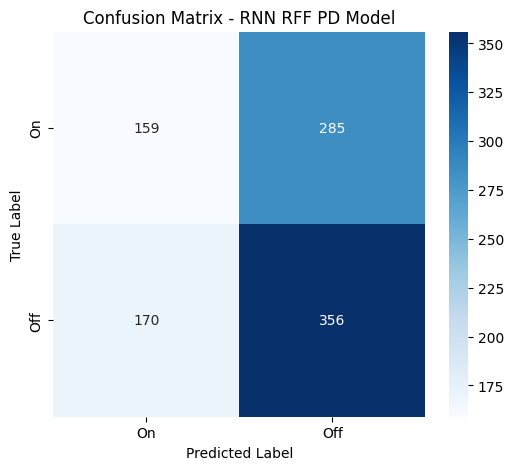

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.36      0.41       444
           1       0.56      0.68      0.61       526

    accuracy                           0.53       970
   macro avg       0.52      0.52      0.51       970
weighted avg       0.52      0.53      0.52       970



In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Step 1: Get Model Predictions
y_pred_probs = model.predict(X_val_rnn)  # Get prediction probabilities


# Step 2: Adjust Decision Threshold
threshold = 0.5
y_pred = (y_pred_probs[:, 0] > threshold).astype(int)

# Step 3: Convert one-hot encoded labels (if needed)
if len(y_val.shape) > 1 and y_val.shape[1] > 1:  # Check safely
    y_test = np.argmax(y_val, axis=1)  # Converts one-hot labels back to single-class


# Step 4: Compute Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

# Step 5: Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["On", "Off"], yticklabels=["On", "Off"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix - RNN RFF PD Model")
plt.show()

# 🔹 Step 6: Print Classification Report
print("Classification Report:\n", classification_report(y_val, y_pred))

# K-Fold

In [13]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

# Define number of folds
k = 5  
kf = KFold(n_splits=k, shuffle=True, random_state=42)

# Store metrics
train_accuracies = []
val_accuracies = []
train_losses = []
val_losses = []

# Placeholder for epoch-wise averaging
all_train_acc = []
all_val_acc = []
all_train_loss = []
all_val_loss = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_full)):
    print(f"\nTraining Fold {fold+1}/{k}")

    y_train = y_train.reset_index(drop=True)

    # Split data
    X_train_fold, X_val_fold = X_train_full[train_idx], X_train_full[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    # Sequential model (LSTM)
    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(X_train_full.shape[1], 1)),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    # Compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                loss="binary_crossentropy",
                metrics=["accuracy"])

    # Train model
    history = model.fit(X_train_fold, y_train_fold, 
                        epochs=20, batch_size=32, 
                        validation_data=(X_val_fold, y_val_fold), 
                        verbose=1)

    # Store per-epoch results
    train_accuracies.append(history.history['accuracy'])
    val_accuracies.append(history.history['val_accuracy'])
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

    # Evaluate model
    _, accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Accuracy: {accuracy:.4f}")


Training Fold 1/5
Epoch 1/20


c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5142 - loss: 0.6930 - val_accuracy: 0.5116 - val_loss: 0.6929
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5164 - loss: 0.6926 - val_accuracy: 0.5116 - val_loss: 0.6929
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5164 - loss: 0.6924 - val_accuracy: 0.5116 - val_loss: 0.6928
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5177 - loss: 0.6923 - val_accuracy: 0.5103 - val_loss: 0.6928
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5168 - loss: 0.6921 - val_accuracy: 0.5090 - val_loss: 0.6929
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.5181 - loss: 0.6920 - val_accuracy: 0.5077 - val_loss: 0.6929
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.5171 - loss: 0.6920 - val_accuracy: 0.5026 - val_loss: 0.6929
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.5203 - loss: 0.6918 - val_accuracy: 0.5000 - val_loss: 0.

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.5145 - loss: 0.6929 - val_accuracy: 0.4961 - val_loss: 0.6933
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5203 - loss: 0.6925 - val_accuracy: 0.4961 - val_loss: 0.6935
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5203 - loss: 0.6924 - val_accuracy: 0.4961 - val_loss: 0.6936
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5203 - loss: 0.6923 - val_accuracy: 0.4961 - val_loss: 0.6937
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5203 - loss: 0.6923 - val_accuracy: 0.4961 - val_loss: 0.6936
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.5203 - loss: 0.6922 - val_accuracy: 0.4961 - val_loss: 0.6938
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5203 - loss: 0.6922 - val_accuracy: 0.4961 - val_loss: 0.6937
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5203 - loss: 0.6923 - val_accuracy: 0.4961 - val_loss: 0.

...

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.5126 - loss: 0.6930 - val_accuracy: 0.5193 - val_loss: 0.6928
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5145 - loss: 0.6928 - val_accuracy: 0.5193 - val_loss: 0.6926
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5148 - loss: 0.6927 - val_accuracy: 0.5193 - val_loss: 0.6925
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5148 - loss: 0.6925 - val_accuracy: 0.5193 - val_loss: 0.6924
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5132 - loss: 0.6924 - val_accuracy: 0.5193 - val_loss: 0.6924
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5148 - loss: 0.6923 - val_accuracy: 0.5180 - val_loss: 0.6924
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5135 - loss: 0.6922 - val_accuracy: 0.5206 - val_loss: 0.6924
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5129 - loss: 0.6920 - val_accuracy: 0.5232 - 

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.5082 - loss: 0.6930 - val_accuracy: 0.5303 - val_loss: 0.6927
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5114 - loss: 0.6929 - val_accuracy: 0.5277 - val_loss: 0.6925
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5121 - loss: 0.6927 - val_accuracy: 0.5277 - val_loss: 0.6922
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5137 - loss: 0.6926 - val_accuracy: 0.5290 - val_loss: 0.6921
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.5140 - loss: 0.6925 - val_accuracy: 0.5316 - val_loss: 0.6921
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.5156 - loss: 0.6925 - val_accuracy: 0.5355 - val_loss: 0.6918
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5221 - loss: 0.6923 - val_accuracy: 0.5290 - val_loss: 0.6921
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5276 - loss: 0.6922 - val_accuracy: 0.5252 - 

c:\Users\basma\OneDrive\Documents\THESIS\QML\qe-feature-representation\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.5118 - loss: 0.6931 - val_accuracy: 0.5303 - val_loss: 0.6929
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5114 - loss: 0.6930 - val_accuracy: 0.5329 - val_loss: 0.6927
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5153 - loss: 0.6928 - val_accuracy: 0.5355 - val_loss: 0.6925
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5134 - loss: 0.6927 - val_accuracy: 0.5277 - val_loss: 0.6923
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5127 - loss: 0.6926 - val_accuracy: 0.5265 - val_loss: 0.6922
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5153 - loss: 0.6925 - val_accuracy: 0.5213 - val_loss: 0.6920
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.5131 - loss: 0.6924 - val_accuracy: 0.5303 - val_loss: 0.6919
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.5176 - loss: 0.6923 - val_accuracy: 0.5239 - 


Final K-Fold Accuracy: 0.5062


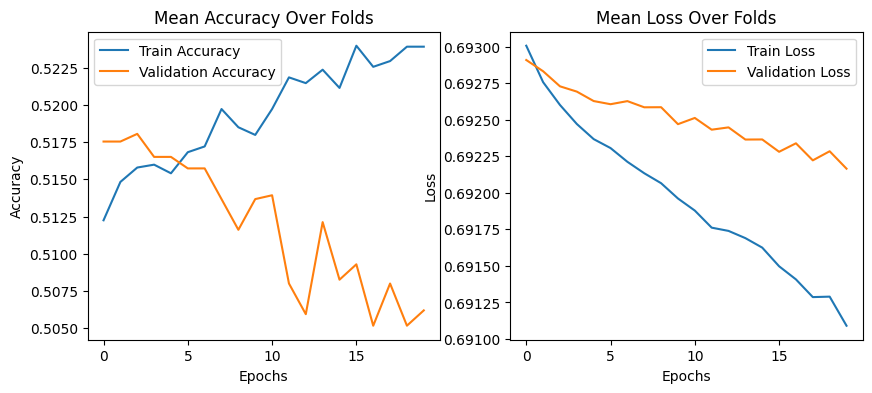

In [14]:
# Convert lists to NumPy arrays for easy averaging
train_accuracies = np.array(train_accuracies)
val_accuracies = np.array(val_accuracies)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)

# Compute mean accuracy/loss across folds
mean_train_acc = np.mean(train_accuracies, axis=0)
mean_val_acc = np.mean(val_accuracies, axis=0)
mean_train_loss = np.mean(train_losses, axis=0)
mean_val_loss = np.mean(val_losses, axis=0)

# 🎯 Final mean accuracy across folds
final_accuracy = np.mean(val_accuracies[:, -1])
print(f"\nFinal K-Fold Accuracy: {final_accuracy:.4f}")

# 📊 Plot Accuracy Curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(mean_train_acc, label='Train Accuracy')
plt.plot(mean_val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Mean Accuracy Over Folds")
plt.legend()

# 📊 Plot Loss Curves
plt.subplot(1, 2, 2)
plt.plot(mean_train_loss, label='Train Loss')
plt.plot(mean_val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Mean Loss Over Folds")
plt.legend()

plt.show()

In [15]:
import pandas as pd
import numpy as np

# Convert lists to numpy arrays
folds = list(range(1, len(train_accuracies) + 1))

# Create DataFrame with results per fold
df_results = pd.DataFrame({
    'Fold': folds,
    'Final Train Accuracy': [train_acc[-1] for train_acc in train_accuracies],
    'Final Validation Accuracy': [val_acc[-1] for val_acc in val_accuracies],
    'Final Train Loss': [train_loss[-1] for train_loss in train_losses],
    'Final Validation Loss': [val_loss[-1] for val_loss in val_losses]
})

# Print results
print("\n📊 K-Fold Cross-Validation Results:\n")
print(df_results)

# Compute summary statistics (mean & std deviation)
df_summary = df_results.describe().loc[['mean', 'std']]
print("\n📌 Summary Statistics (Mean & Std Deviation):\n")
print(df_summary)


📊 K-Fold Cross-Validation Results:

   Fold  Final Train Accuracy  Final Validation Accuracy  Final Train Loss  \
0     1              0.523856                   0.497423          0.690803   
1     2              0.519987                   0.494845          0.691781   
2     3              0.526435                   0.503866          0.691096   
3     4              0.525943                   0.516129          0.690715   
4     5              0.523364                   0.518710          0.691057   

   Final Validation Loss  
0               0.693226  
1               0.692496  
2               0.693051  
3               0.691455  
4               0.690598  

📌 Summary Statistics (Mean & Std Deviation):

          Fold  Final Train Accuracy  Final Validation Accuracy  \
mean  3.000000              0.523917                   0.506195   
std   1.581139              0.002559                   0.010799   

      Final Train Loss  Final Validation Loss  
mean          0.691090             